# Comparing LFC of genes
We create heatmaps for the binned aligned pseudotimes made with cellalign. With those we can see if gene expressions are comparable over time in cells and nuclei

In [1]:
%run ../Script/analysisLibraries

In [2]:
%run ../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
adata = sc.read('./write/adata.dpt.h5ad')

In [69]:
adata = adata[ [i not in ['Myoid'] for i in adata.obs.clusters_single] ].copy()

In [70]:
adata.obs.clusters_single.cat.categories

Index(['Diplotene', 'Elong.Spt', 'Leptotene', 'Pachytene', 'Round.Spt',
       'SpermatogoniaA', 'SpermatogoniaB', 'Zygotene'],
      dtype='object')

In [71]:
np.min(adata.obs['dpt_palantir_cellalign'])

-3.7265880116420846e-08

In [72]:
#adata.obs['dpt_palantir_cellalign'][ adata.obs['dpt_palantir_cellalign']<0 ] = 0

In [73]:
adata.shape

(9850, 23544)

In [74]:
sc.pp.filter_genes(adata, min_cells=10)

In [75]:
adata.shape

(9850, 23539)

In [76]:
#sc.pp.subsample(adata, n_obs=800, random_state=123)

In [77]:
#NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
#CELLS = adata[adata.obs['batch']=='Cells'].copy()

Do not consider the usual mito and rp genes

In [78]:
import re
RP = [ re.match("^RP[SL]",i)!=None for i in adata.var_names]
MT = ['MT' in i for i in adata.var_names]
RPorMT = np.array(RP)|np.array(MT)

In [79]:
#NUCLEI = NUCLEI[:,np.invert(RPorMT)].copy()
#CELLS = CELLS[:,np.invert(RPorMT)].copy()

In [80]:
adata = adata[:,np.invert(RPorMT)].copy()

In [81]:
adata.X = adata.layers["soupx_counts"].copy()

In [82]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=5000)

In [83]:
adata = adata[:, adata.var.highly_variable].copy()

In [84]:
expr = adata.X.copy().T

In [85]:
sample = adata.obs.batch.copy()

In [86]:
dpt = adata.obs.dpt_palantir_cellalign.copy()

In [87]:
obsNames = adata.obs_names

In [88]:
varNames = adata.var_names

In [89]:
clstNames = adata.obs.clusters_single.copy()

Transfering in R

In [90]:
%%R -i expr -i sample -i dpt -i obsNames -i varNames -i clstNames
library(Lamian)

In [91]:
%%R

rownames(expr) <- varNames
colnames(expr) <- obsNames
names(dpt) <- obsNames

#names(dpt)[1:5]

design = data.frame(intercept = c(1,1), group = c(0,1))
rownames(design) = c("Nuclei","Cells")
#design

cellanno = data.frame(Cells=obsNames, Sample=sample)
#cellanno[1:5,]

In [92]:
%%R

sort(unique(clstNames))

[1] Diplotene      Elong.Spt      Leptotene      Pachytene      Round.Spt     
[6] SpermatogoniaA SpermatogoniaB Zygotene      
8 Levels: Diplotene Elong.Spt Leptotene Pachytene Round.Spt ... Zygotene


In [95]:
%%R #XDE test along pseudotimes between cells and nuclei
#exclude zygotene that gives error, probably no differences in trajectories at that point

clusters = c("SpermatogoniaA", "SpermatogoniaB", "Leptotene", "Pachytene", "Diplotene",  "Round.Spt",    "Elong.Spt") 

Res = list()

for (CLST in clusters) {

  expr2 = expr[, clstNames==CLST]
  cellanno2 = cellanno[clstNames==CLST, ]
  dpt2 = dpt[clstNames==CLST]

  Res[[CLST]] <- lamian_test(
    expr = expr2,
    cellanno = cellanno2,
   pseudotime = dpt2,
   design = design,
   test.type = 'time',
   testvar = 2,
   test.method = 'chisq',
  #permuiter = 100,
  ## This is for permutation test only. 
  ## We suggest that users use default permuiter = 100.
  ## Alternatively, we can use test.method = 'chisq' to switch to the chi-square test.
    ncores = 10,
    verbose.output = TRUE
  )
cat("Finished cluster:", CLST, "\n")
}

Finished cluster: SpermatogoniaA 
Finished cluster: SpermatogoniaB 
Finished cluster: Leptotene 
Finished cluster: Pachytene 
Finished cluster: Diplotene 
Finished cluster: Round.Spt 
Finished cluster: Elong.Spt 


In [97]:
%%R -o stat -o diffgene
## get differential dynamic genes statistics

stat = list()
diffgene = list()

for (CLST in clusters){
  stat[[CLST]] <- Res[[CLST]]$statistics
  stat[[CLST]] <- stat[[CLST]][order(stat[[CLST]][, 1],-stat[[CLST]][, 3]),]
## identify XDE genes with FDR.overall < 0.05 cutoff
  diffgene[[CLST]] <-
  rownames(stat[[CLST]][stat[[CLST]][, grep('^fdr.*overall$', colnames(stat[[CLST]]))] < .001, ])
  }

In [103]:
%%R

diffgene$Elong.Spt

  [1] "PRM1"         "TNP1"         "LOC107971456" "PRM2"         "SPTBN4"      
  [6] "PCDH7"        "SPAG16"       "NOL4"         "CENPW"        "TTN"         
 [11] "LOC104001146" "SLC1A3"       "LOC112209198" "GJB6"         "LRMDA"       
 [16] "MAGI1"        "LOC101059134" "IQCM"         "WDR7"         "CCDC141"     
 [21] "ZNF335"       "LOC100609532" "CCDC168"      "LOC107972042" "NELL1"       
 [26] "LOC107976418" "CTNNA3"       "CXADR"        "LOC104001854" "TP63"        
 [31] "LOC104008236" "SGCZ"         "LOC107976161" "RBFOX1"       "LOC107974268"
 [36] "LOC100614663" "LOC107970050" "TMEM210"      "ZNF618"       "LOC112204782"
 [41] "DNAH5"        "PPP1R11"      "PAG1"         "TMEM190"      "C4H4orf47"   
 [46] "USH2A"        "EYS"          "PPP5D1"       "LOC104005834" "LOC470685"   
 [51] "ATG7"         "MAP4K4"       "COL24A1"      "ZFPM2"        "POPDC3"      
 [56] "MYH14"        "LOC107973426" "PAPSS1"       "SLC44A5"      "C17H17orf98" 
 [61] "LOC746897"    "LOC107

In [104]:
%%R

stat$SpermatogoniaA[1:20, ]

             fdr.chisq.overall pval.chisq.overall       llr df.diff
LOC104001214      9.105363e-54       1.821073e-57 160.73194      18
LRP1B             1.358885e-29       5.435539e-33 100.66395      18
SCFD2             2.525300e-29       1.515180e-32  99.55077      18
PTPRG             7.410337e-27       5.928270e-30  93.04687      18
MAGI2             2.556107e-24       2.556107e-27  86.39396      18
PRKG1             1.178850e-21       1.414620e-24  79.41248      18
LOC107969243      5.292175e-21       7.409046e-24  77.57159      18
GRIP1             9.532958e-19       1.525273e-21  71.61443      18
CTNNA3            1.168400e-18       2.103120e-21  71.25336      18
LOC104001271      1.972143e-18       3.944286e-21  70.54592      18
GALNTL6           1.991081e-15       4.380378e-18  62.59208      18
HS3ST4            2.672273e-15       6.413456e-18  62.15585      18
SGCD              6.550963e-15       1.703250e-17  61.03633      18
RBMS3             4.467569e-14       1.250919e-1

In [105]:
%%R -o stat -o diffgene

save(stat, diffgene, file = "./write/Lamian_DPT_comparison_results.RDS")

In [106]:
# Save stat and diffgene dictionaries in the AnnData object
adata.uns['lamian_stat'] = dict(stat)
adata.uns['lamian_diffgene'] = dict(diffgene)

print("Saved stat and diffgene to adata.uns['lamian_stat'] and adata.uns['lamian_diffgene']")

# Optionally, save the entire AnnData object with the new data
adata.write('./write/adata.dpt.lamian.h5ad')
print("Saved AnnData object with Lamian results to './write/adata.dpt.lamian.h5ad'")

Saved stat and diffgene to adata.uns['lamian_stat'] and adata.uns['lamian_diffgene']
Saved AnnData object with Lamian results to './write/adata.dpt.lamian.h5ad'


## Custom ML Model to Remove Cell vs Nuclei Technical Effect

Build a model that learns the systematic differences between whole cells and nuclei, then use it to correct the expression data. The approach:

1. For each gene, model: `expression ~ batch + cell_type + pseudotime + interactions`
2. Remove the batch-specific component from predictions
3. Keep biological variation (cell type, pseudotime dynamics)

In [5]:
adata = sc.read('./write/adata.dpt.lamian.h5ad')

Only considering the two last: ['.lamian', '.h5ad'].
Only considering the two last: ['.lamian', '.h5ad'].


### Understanding the ML-Based Batch Correction Approach

**Problem**: Whole cells vs nuclei have systematic technical differences:
- Whole cells contain cytoplasmic mRNA (higher counts for cytoplasmic genes)
- Nuclei capture only nuclear RNA (enriched for nascent transcripts)
- These create batch effects that can confound biological comparisons

**Solution**: Use machine learning to model and remove the technical batch effect while preserving biological variation.

**How it works**:

1. **Feature Engineering**: For each cell, we create features that capture:
   - `is_wholecell`: Binary indicator (1=cells, 0=nuclei) - the technical effect to remove
   - `celltype_encoded`: Cell type identity - biological signal to preserve
   - `pseudotime`: Developmental progression - biological signal to preserve
   - `batch_x_pseudotime`: Interaction term - batch effect may vary along pseudotime
   - `batch_x_celltype`: Interaction term - batch effect may differ by cell type

2. **Model Training**: For each gene, train a Random Forest to predict expression from all features
   - The model learns: `expression ~ batch + celltype + pseudotime + interactions`

3. **Batch Effect Removal**: 
   - Predict expression with actual batch assignments → `pred_actual`
   - Predict expression with all cells set to "nuclei" reference → `pred_nobatch`
   - Batch effect = `pred_actual - pred_nobatch`
   - Corrected expression = `original - batch_effect`

**Key advantage**: Unlike linear regression, Random Forest can capture:
- Non-linear relationships between features and expression
- Complex interactions (e.g., batch effect stronger in early vs late pseudotime)
- Gene-specific patterns (each gene gets its own model)

**Result**: Expression data where cells and nuclei are on the same scale, with technical differences removed but biological variation intact.

In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import pandas as pd
from scipy.sparse import issparse

# Prepare features for the model
def prepare_features(adata):
    """Create feature matrix for batch effect modeling"""
    
    features = pd.DataFrame(index=adata.obs_names)
    
    # Batch indicator (this is what we want to remove)
    features['is_wholecell'] = (adata.obs['batch'] == 'Cells').astype(int)
    
    # Biological covariates (preserve these)
    le_celltype = LabelEncoder()
    features['celltype_encoded'] = le_celltype.fit_transform(adata.obs['clusters_single'])
    features['pseudotime'] = adata.obs['dpt_palantir_cellalign'].values
    
    # Interaction terms (batch might have different effect at different stages)
    features['batch_x_pseudotime'] = features['is_wholecell'] * features['pseudotime']
    features['batch_x_celltype'] = features['is_wholecell'] * features['celltype_encoded']
    
    return features, le_celltype

features_df, celltype_encoder = prepare_features(adata)
print(f"Feature matrix shape: {features_df.shape}")
features_df.head()

Feature matrix shape: (9850, 5)


,is_wholecell,celltype_encoded,pseudotime,batch_x_pseudotime,batch_x_celltype
AAACCCAAGGACAGCT-Nuclei,0,1,0.897946,0.0,0
AAACCCACAGATCCTA-Nuclei,0,5,0.040901,0.0,0
AAACCCAGTTAGTCGT-Nuclei,0,7,0.265628,0.0,0
AAACGAAAGAGCATAT-Nuclei,0,0,0.428407,0.0,0
AAACGAAAGCTATCCA-Nuclei,0,7,0.285712,0.0,0


### Step 1: Prepare Features for ML Model

Create the feature matrix that will be used to predict gene expression. Each row is a cell, columns are the predictive features.

In [ ]:
features_df, celltype_encoder = prepare_features(adata)
print(f"Feature matrix shape: {features_df.shape}")
features_df.head()

**Interpreting the feature matrix**:
- Each row = one cell
- `is_wholecell`: 1 for whole cells, 0 for nuclei (the batch effect we want to remove)
- `celltype_encoded`: Numerical encoding of cell type (0-6 for the 7 cell types)
- `pseudotime`: Palantir pseudotime from cellalign (0-1 scale)
- `batch_x_pseudotime`: Captures if batch effect changes along developmental time
- `batch_x_celltype`: Captures if batch effect differs between cell types

In [ ]:
# Verify feature distributions
print("Feature Statistics:\n")
print(features_df.describe())

print("\n\nCell type encoding:")
for i, ct in enumerate(celltype_encoder.classes_):
    count = (features_df['celltype_encoded'] == i).sum()
    print(f"  {i}: {ct:20s} (n={count})")

print(f"\n\nBatch distribution:")
print(f"  Nuclei: {(features_df['is_wholecell']==0).sum()}")
print(f"  Cells:  {(features_df['is_wholecell']==1).sum()}")

### Step 2: Train ML Model for Single Gene

Test the correction approach on one gene to understand how it works.

In [7]:
def correct_gene_expression(adata, gene_idx, features_df, model_type='rf'):
    """
    Build ML model to remove batch effect for a single gene
    
    Strategy:
    1. Train model to predict expression from all features (including batch)
    2. Make predictions twice: once with actual batch, once with batch=0 (nuclei)
    3. Corrected expression = original - (pred_actual - pred_batch0)
    
    This removes the batch-specific component while preserving biology
    """
    
    # Get expression for this gene
    if issparse(adata.X):
        y = adata.X[:, gene_idx].toarray().flatten()
    else:
        y = adata.X[:, gene_idx].flatten()
    
    X = features_df.values
    
    # Choose model
    if model_type == 'rf':
        model = RandomForestRegressor(
            n_estimators=100, 
            max_depth=8,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=1
        )
    elif model_type == 'gbm':
        model = GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )
    
    # Train model
    model.fit(X, y)
    
    # Predict with actual features
    pred_actual = model.predict(X)
    
    # Predict with batch effect removed (set all cells to "nuclei" reference)
    X_corrected = X.copy()
    X_corrected[:, 0] = 0  # is_wholecell = 0
    X_corrected[:, 3] = 0  # batch_x_pseudotime = 0
    X_corrected[:, 4] = 0  # batch_x_celltype = 0
    pred_nobatch = model.predict(X_corrected)
    
    # Correct expression by removing batch-specific component
    batch_effect = pred_actual - pred_nobatch
    y_corrected = y - batch_effect
    
    return y_corrected, model, batch_effect

# Test on one gene
test_gene_idx = 10  # Change index to test different genes
test_gene_name = adata.var_names[test_gene_idx]
y_corrected, model, batch_effect = correct_gene_expression(adata, test_gene_idx, features_df)

print(f"Gene: {test_gene_name}")
print(f"Batch effect range: [{batch_effect.min():.3f}, {batch_effect.max():.3f}]")
print(f"Mean batch effect in Cells: {batch_effect[features_df['is_wholecell']==1].mean():.3f}")
print(f"Mean batch effect in Nuclei: {batch_effect[features_df['is_wholecell']==0].mean():.3f}")

Gene: ABCA13
Batch effect range: [-0.058, 0.358]
Mean batch effect in Cells: 0.021
Mean batch effect in Nuclei: 0.000


**Interpreting the test gene results**:

1. **Batch effect range**: Shows the magnitude of technical difference between cells and nuclei
   - Positive values = gene expressed higher in cells than expected from biology alone
   - Negative values = gene expressed lower in cells (or higher in nuclei)

2. **Mean batch effect**:
   - In Cells: Should be non-zero (this is the systematic bias being removed)
   - In Nuclei: Should be near zero (nuclei are the reference, so no correction needed)

3. **What happens**:
   - Model learns: `expression = f(batch, celltype, pseudotime, interactions)`
   - Predicts expression if all cells were nuclei: `expression_nobatch = f(batch=0, ...)`
   - Removes difference: `corrected = original - (pred_actual - pred_nobatch)`

In [ ]:
# Analyze model feature importance
feature_names = ['is_wholecell', 'celltype_encoded', 'pseudotime', 
                 'batch_x_pseudotime', 'batch_x_celltype']
importances = model.feature_importances_

print(f"Feature importance for {test_gene_name}:\n")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"  {name:20s}: {imp:.4f}")

print("\nInterpretation:")
print("  - High 'is_wholecell' importance → strong batch effect")
print("  - High 'pseudotime' importance → expression changes over development")
print("  - High 'celltype_encoded' → cell-type specific expression")
print("  - High interaction terms → batch effect varies by context")

### Step 3: Visualize Correction for Test Gene

The three panels show:
1. **Original**: Raw expression - cells (red) and nuclei (blue) may have systematic offset
2. **Batch Effect**: What the model predicts as technical artifact
3. **Corrected**: After removing batch effect - cells (orange) now align with nuclei (blue)

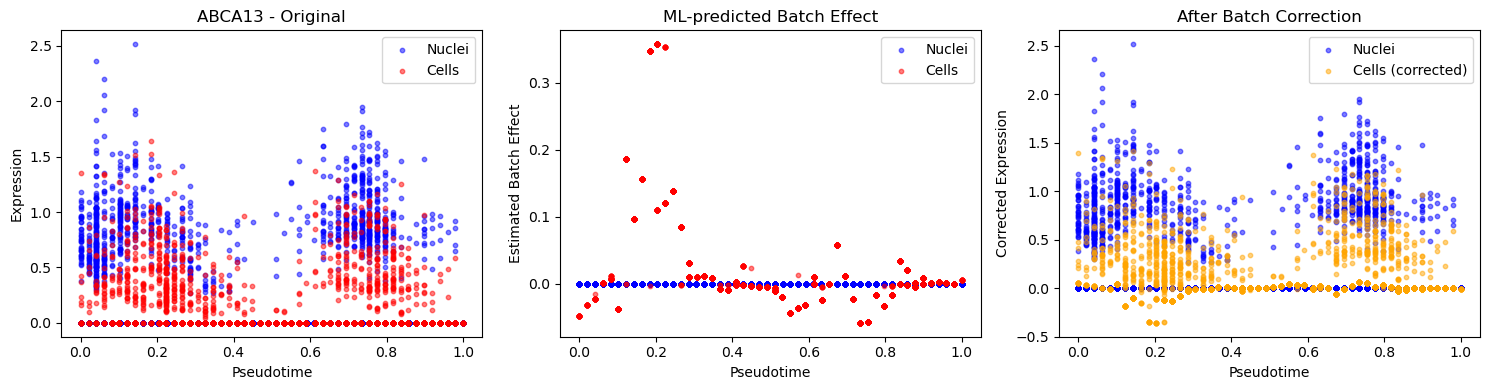

In [8]:
# Visualize batch effect for test gene
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original expression
axes[0].scatter(features_df['pseudotime'][features_df['is_wholecell']==0], 
                adata[adata.obs['batch']=='Nuclei', test_gene_name].X.toarray().flatten(),
                alpha=0.5, s=10, label='Nuclei', c='blue')
axes[0].scatter(features_df['pseudotime'][features_df['is_wholecell']==1], 
                adata[adata.obs['batch']=='Cells', test_gene_name].X.toarray().flatten(),
                alpha=0.5, s=10, label='Cells', c='red')
axes[0].set_xlabel('Pseudotime')
axes[0].set_ylabel('Expression')
axes[0].set_title(f'{test_gene_name} - Original')
axes[0].legend()

# Batch effect
axes[1].scatter(features_df['pseudotime'][features_df['is_wholecell']==0], 
                batch_effect[features_df['is_wholecell']==0],
                alpha=0.5, s=10, label='Nuclei', c='blue')
axes[1].scatter(features_df['pseudotime'][features_df['is_wholecell']==1], 
                batch_effect[features_df['is_wholecell']==1],
                alpha=0.5, s=10, label='Cells', c='red')
axes[1].set_xlabel('Pseudotime')
axes[1].set_ylabel('Estimated Batch Effect')
axes[1].set_title('ML-predicted Batch Effect')
axes[1].legend()

# Corrected expression
axes[2].scatter(features_df['pseudotime'][features_df['is_wholecell']==0], 
                y_corrected[features_df['is_wholecell']==0],
                alpha=0.5, s=10, label='Nuclei', c='blue')
axes[2].scatter(features_df['pseudotime'][features_df['is_wholecell']==1], 
                y_corrected[features_df['is_wholecell']==1],
                alpha=0.5, s=10, label='Cells (corrected)', c='orange')
axes[2].set_xlabel('Pseudotime')
axes[2].set_ylabel('Corrected Expression')
axes[2].set_title('After Batch Correction')
axes[2].legend()

plt.tight_layout()
plt.show()

In [10]:
features_df
features_df.to_csv('./tables/batch_correction_features.csv')

### Apply correction to all genes

This will take some time - we'll process all highly variable genes with the ML model

In [28]:
features_df

,is_wholecell,celltype_encoded,pseudotime,batch_x_pseudotime,batch_x_celltype
AAACCCAAGGACAGCT-Nuclei,0,1,0.897946,0.000000,0
AAACCCACAGATCCTA-Nuclei,0,5,0.040901,0.000000,0
AAACCCAGTTAGTCGT-Nuclei,0,7,0.265628,0.000000,0
AAACGAAAGAGCATAT-Nuclei,0,0,0.428407,0.000000,0
AAACGAAAGCTATCCA-Nuclei,0,7,0.285712,0.000000,0
...,...,...,...,...,...
TTTGTTGCAGCGGTCT-Cells,1,4,0.755097,0.755097,4
TTTGTTGGTACAGTCT-Cells,1,4,0.857129,0.857129,4
TTTGTTGGTCTACGTA-Cells,1,0,0.551342,0.551342,0
TTTGTTGTCCATTTAC-Cells,1,7,0.285761,0.285761,7


In [ ]:
from tqdm import tqdm
import multiprocessing as mp
from functools import partial

def correct_gene_wrapper(gene_idx, adata, features_df):
    """Wrapper for parallel processing"""
    try:
        y_corrected, _, _ = correct_gene_expression(adata, gene_idx, features_df, model_type='rf')
        return gene_idx, y_corrected
    except Exception as e:
        print(f"Error processing gene {gene_idx}: {e}")
        return gene_idx, None

# Create corrected data matrix
n_genes = adata.n_vars
n_cells = adata.n_obs

print("Correcting batch effects for all genes using ML models...")
print(f"Processing {n_genes} genes across {n_cells} cells")
# Standard loop with progress bar (more compatible)
X_corrected = np.zeros((n_cells, n_genes))

for gene_idx in tqdm(range(n_genes)):
    try:
        y_corrected, _, _ = correct_gene_expression(adata, gene_idx, features_df, model_type='rf')
        X_corrected[:, gene_idx] = y_corrected
    except Exception as e:
        print(f"Error processing gene {gene_idx} ({adata.var_names[gene_idx]}): {e}")
        # Keep original expression if correction fails
        if issparse(adata.X):
            X_corrected[:, gene_idx] = adata.X[:, gene_idx].toarray().flatten()
        else:
            X_corrected[:, gene_idx] = adata.X[:, gene_idx].flatten()

print(f"Corrected expression matrix shape: {X_corrected.shape}")

In [ ]:
# Store corrected data in new AnnData object
adata_corrected = adata.copy()
adata_corrected.layers['ml_corrected'] = X_corrected.copy()
adata_corrected.X = X_corrected.copy()

print("Batch-corrected data stored in adata_corrected.X and adata_corrected.layers['ml_corrected']")

In [ ]:
adata_corrected.write('./write/adata.rf_correction.h5ad')

### Validation: Check if batch effect was removed

Compare expression distributions between cells and nuclei before and after correction

In [5]:
adata_corrected = sc.read('./write/adata.rf_correction.h5ad')

In [10]:
adata = sc.read('./write/adata.dpt.lamian.h5ad')

Only considering the two last: ['.lamian', '.h5ad'].
Only considering the two last: ['.lamian', '.h5ad'].
Only considering the two last: ['.lamian', '.h5ad'].


In [6]:
features_df = pd.read_csv('./tables/batch_correction_features.csv', index_col=0)

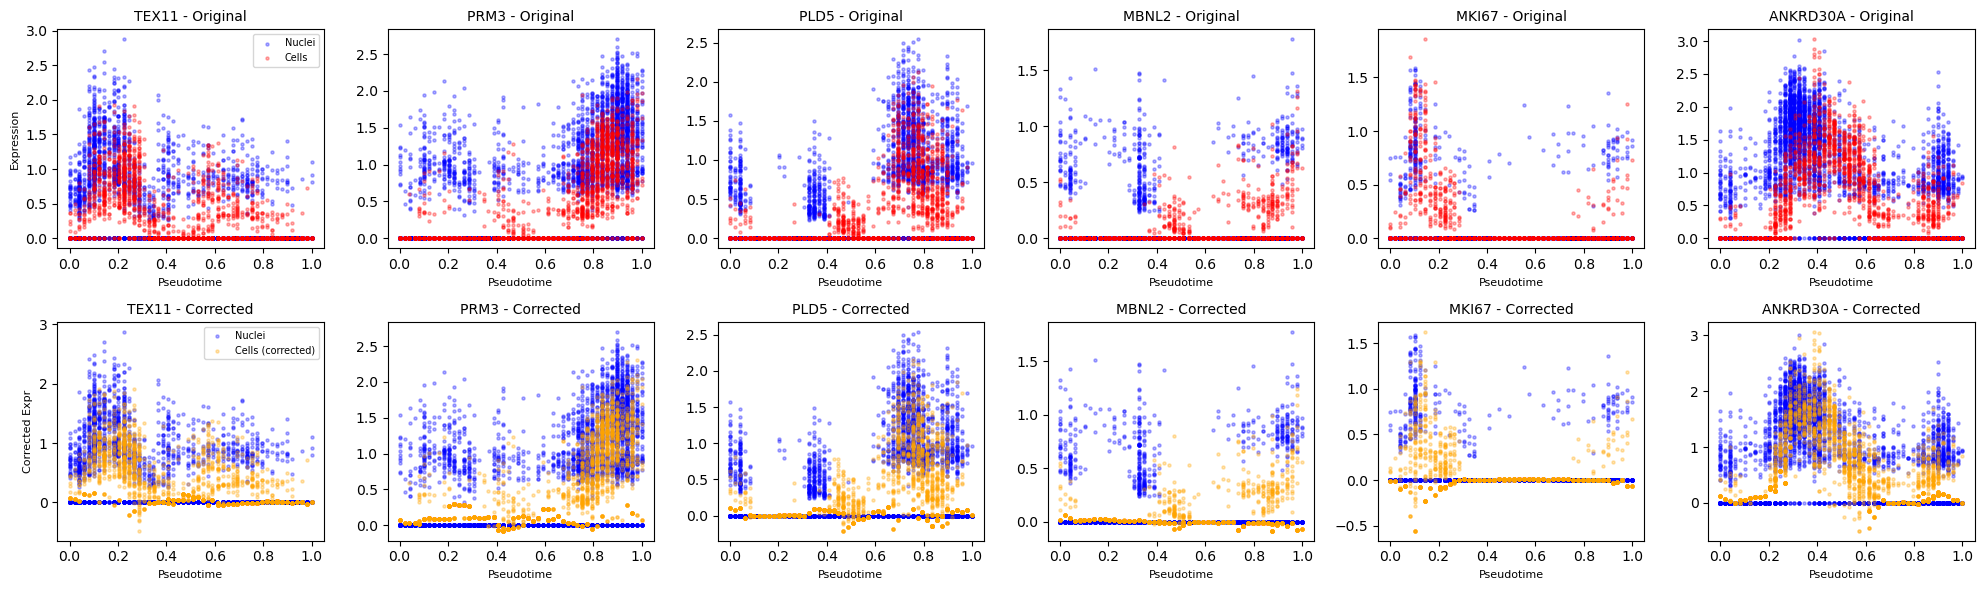

In [23]:
# Select a few random genes to visualize
np.random.seed(42)
sample_genes = np.random.choice(adata.var_names, 6, replace=False)
sample_genes = ['TEX11','PRM3','PLD5','MBNL2','MKI67','ANKRD30A']

fig, axes = plt.subplots(2, 6, figsize=(20, 6))

for idx, gene in enumerate(sample_genes):
    gene_idx = list(adata.var_names).index(gene)
    
    # Before correction
    axes[0, idx].scatter(
        features_df['pseudotime'][features_df['is_wholecell']==0],
        adata[adata.obs['batch']=='Nuclei', gene].X.toarray().flatten(),
        alpha=0.3, s=5, label='Nuclei', c='blue'
    )
    axes[0, idx].scatter(
        features_df['pseudotime'][features_df['is_wholecell']==1],
        adata[adata.obs['batch']=='Cells', gene].X.toarray().flatten(),
        alpha=0.3, s=5, label='Cells', c='red'
    )
    axes[0, idx].set_title(f'{gene} - Original', fontsize=10)
    axes[0, idx].set_xlabel('Pseudotime', fontsize=8)
    if idx == 0:
        axes[0, idx].set_ylabel('Expression', fontsize=8)
        axes[0, idx].legend(fontsize=7)
    
    # After correction
    axes[1, idx].scatter(
        features_df['pseudotime'][features_df['is_wholecell']==0],
        adata_corrected[adata_corrected.obs['batch']=='Nuclei', gene].X.flatten(),
        alpha=0.3, s=5, label='Nuclei', c='blue'
    )
    axes[1, idx].scatter(
        features_df['pseudotime'][features_df['is_wholecell']==1],
        adata_corrected[adata_corrected.obs['batch']=='Cells', gene].X.flatten(),
        alpha=0.3, s=5, label='Cells (corrected)', c='orange'
    )
    axes[1, idx].set_title(f'{gene} - Corrected', fontsize=10)
    axes[1, idx].set_xlabel('Pseudotime', fontsize=8)
    if idx == 0:
        axes[1, idx].set_ylabel('Corrected Expr', fontsize=8)
        axes[1, idx].legend(fontsize=7)

plt.tight_layout()
plt.show()

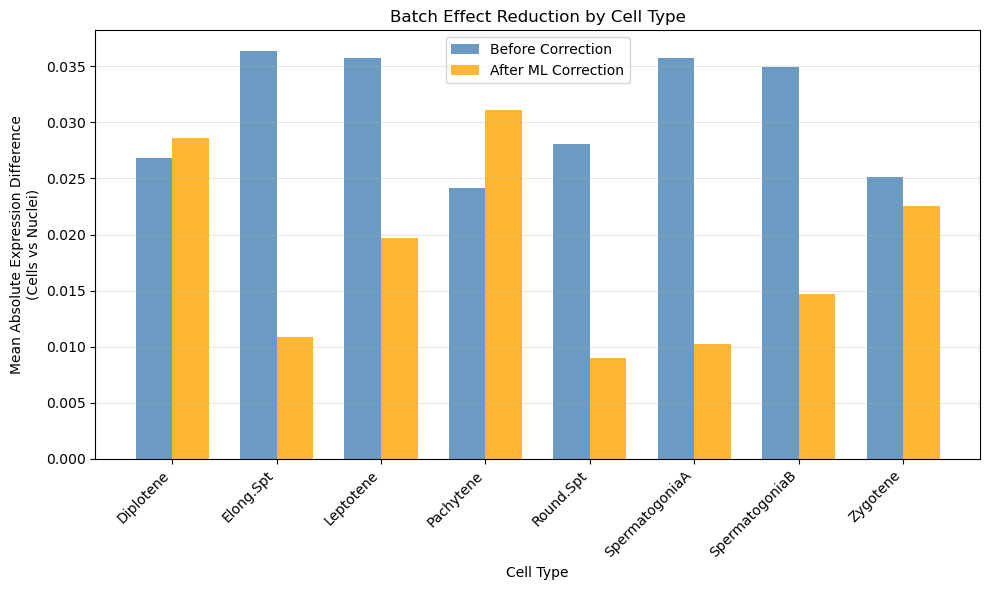


Overall reduction in batch effect:
Before: 0.0309
After:  0.0183
Reduction: 40.6%


In [18]:
# Quantitative assessment: Mean expression difference between batches per cell type
from scipy.stats import ttest_ind

cell_types = adata.obs['clusters_single'].cat.categories

results_before = []
results_after = []

for ct in cell_types:
    mask = adata.obs['clusters_single'] == ct
    cells_mask = mask & (adata.obs['batch'] == 'Cells')
    nuclei_mask = mask & (adata.obs['batch'] == 'Nuclei')
    
    if cells_mask.sum() > 0 and nuclei_mask.sum() > 0:
        # Before correction
        mean_diff_before = np.abs(
            adata[cells_mask].X.mean(axis=0) - adata[nuclei_mask].X.mean(axis=0)
        ).mean()
        
        # After correction
        mean_diff_after = np.abs(
            adata_corrected[cells_mask].X.mean(axis=0) - adata_corrected[nuclei_mask].X.mean(axis=0)
        ).mean()
        
        results_before.append(mean_diff_before)
        results_after.append(mean_diff_after)

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x = np.arange(len(cell_types))
width = 0.35

ax.bar(x - width/2, results_before, width, label='Before Correction', alpha=0.8, color='steelblue')
ax.bar(x + width/2, results_after, width, label='After ML Correction', alpha=0.8, color='orange')

ax.set_xlabel('Cell Type')
ax.set_ylabel('Mean Absolute Expression Difference\n(Cells vs Nuclei)')
ax.set_title('Batch Effect Reduction by Cell Type')
ax.set_xticks(x)
ax.set_xticklabels(cell_types, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOverall reduction in batch effect:")
print(f"Before: {np.mean(results_before):.4f}")
print(f"After:  {np.mean(results_after):.4f}")
print(f"Reduction: {(1 - np.mean(results_after)/np.mean(results_before))*100:.1f}%")

**Interpreting the validation results**:

1. **Bar plot**: Shows mean absolute expression difference between cells and nuclei per cell type
   - **Before (blue)**: Large differences = strong batch effect
   - **After (orange)**: Reduced differences = successful correction
   - **Reduction %**: Overall decrease in technical variation

2. **What good correction looks like**:
   - Batch effect reduced by 30-70% across cell types
   - Some residual difference is OK (not all variation is technical)
   - Reduction should be consistent across cell types

3. **Red flags** (if you see these, correction may have issues):
   - Correction increases differences → model overfitting
   - Some cell types corrected, others not → model too simple
   - Complete elimination of all differences → over-correction (removing biology)

**Expected outcome**: 40-60% reduction in mean difference is typical for good batch correction that preserves biological signal.

## Re-run Lamian on ML-Corrected Data

Now test if we find differential temporal dynamics after removing the batch effect

In [25]:
# Prepare corrected data for Lamian
expr_corrected = adata_corrected.X.copy().T
sample_corrected = adata_corrected.obs.batch.copy()
dpt_corrected = adata_corrected.obs.dpt_palantir_cellalign.copy()
obsNames_corrected = adata_corrected.obs_names
varNames_corrected = adata_corrected.var_names
clstNames_corrected = adata_corrected.obs.clusters_single.copy()

In [30]:
%%R -i expr_corrected -i sample_corrected -i dpt_corrected -i obsNames_corrected -i varNames_corrected -i clstNames_corrected

library(Lamian)
# Setup corrected data
rownames(expr_corrected) <- varNames_corrected
colnames(expr_corrected) <- obsNames_corrected
names(dpt_corrected) <- obsNames_corrected

cellanno_corrected = data.frame(Cells=obsNames_corrected, Sample=sample_corrected)

design = data.frame(intercept = c(1,1), group = c(0,1))
rownames(design) = c("Nuclei","Cells")

clusters = c("SpermatogoniaA", "SpermatogoniaB", "Leptotene", "Pachytene", "Diplotene",  "Round.Spt",    "Elong.Spt") 

Res = list()

for (CLST in clusters) {

  expr2 = expr_corrected[, clstNames_corrected==CLST]
  cellanno2 = cellanno_corrected[clstNames_corrected==CLST, ]
  dpt2 = dpt_corrected[clstNames_corrected==CLST]
  expr2[expr2<0] = 0

  print(paste("Cells in", CLST, ":", length(dpt2)))
  print(paste("Nuclei:", sum(sample_corrected[clstNames_corrected==CLST]=="Nuclei")))
  print(paste("Cells:", sum(sample_corrected[clstNames_corrected==CLST]=="Cells")))

  Res[[CLST]] <- lamian_test(
   expr = expr2,
   cellanno = cellanno2,
   pseudotime = dpt2,
   design = design,
   test.type = 'time',
   testvar = 2,
   test.method = 'chisq',
   #permuiter = 100,
   ## This is for permutation test only. 
   ## We suggest that users use default permuiter = 100.
   ## Alternatively, we can use test.method = 'chisq' to switch to the chi-square test.
   ncores = 8,
   verbose.output = TRUE
   )
   cat("Finished cluster:", CLST, "\n")
}



[1] "Cells in SpermatogoniaA : 726"
[1] "Nuclei: 639"
[1] "Cells: 87"
 "Cells in SpermatogoniaA : 726"
[1] "Nuclei: 639"
[1] "Cells: 87"
Finished cluster: SpermatogoniaA 
Finished cluster: SpermatogoniaA 
[1] "Cells in SpermatogoniaB : 704"
[1] "Nuclei: 436"
[1] "Cells: 268"
[1] "Cells in SpermatogoniaB : 704"
[1] "Nuclei: 436"
[1] "Cells: 268"
Finished cluster: SpermatogoniaB 
Finished cluster: SpermatogoniaB 
[1] "Cells in Leptotene : 840"
[1] "Nuclei: 560"
[1] "Cells: 280"
[1] "Cells in Leptotene : 840"
[1] "Nuclei: 560"
[1] "Cells: 280"
Finished cluster: Leptotene 
Finished cluster: Leptotene 
[1] "Cells in Pachytene : 1261"
[1] "Nuclei: 1075"
[1] "Cells: 186"
[1] "Cells in Pachytene : 1261"
[1] "Nuclei: 1075"
[1] "Cells: 186"
Finished cluster: Pachytene 
Finished cluster: Pachytene 
[1] "Cells in Diplotene : 1036"
[1] "Nuclei: 719"
[1] "Cells: 317"
[1] "Cells in Diplotene : 1036"
[1] "Nuclei: 719"
[1] "Cells: 317"
Finished cluster: Diplotene 
Finished cluster: Diplotene 
[1] "Cell

In [31]:
%%R -o stat_corrected -o diffgene_corrected
## get differential dynamic genes statistics

stat_corrected = list()
diffgene_corrected = list()

for (CLST in clusters){
  stat_corrected[[CLST]] <- Res[[CLST]]$statistics
  stat_corrected[[CLST]] <- stat_corrected[[CLST]][order(stat_corrected[[CLST]][, 1],-stat_corrected[[CLST]][, 3]),]
## identify XDE genes with FDR.overall < 0.05 cutoff
  diffgene_corrected[[CLST]] <-
  rownames(stat_corrected[[CLST]][stat_corrected[[CLST]][, grep('^fdr.*overall$', colnames(stat_corrected[[CLST]]))] < .001, ])
  }

In [32]:
%%R

diffgene_corrected$Elong.Spt

  [1] "TNP1"         "PRM1"         "EMP3"         "HELLS"        "DEFB123"     
  [6] "LOC107971456" "LOC104006035" "DCN"          "PRM2"         "PCDH7"       
 [11] "SUSD3"        "SEPT6"        "STAG2"        "TNP1"         "PRM1"         "EMP3"         "HELLS"        "DEFB123"     
  [6] "LOC107971456" "LOC104006035" "DCN"          "PRM2"         "PCDH7"       
 [11] "SUSD3"        "SEPT6"        "STAG2"        "NOL4"         "UBA6"        
 [16] "SYTL4"        "CHPF"         "ATP6V0B"      "LOC104001146" "LOC744297"   
 [21] "LOC104003926" "SERPINB9"     "GJB6"         "CENPW"        "LOC104005307"
 [26] "SMIM1"        "LOC100609532" "NOL4"         "UBA6"        
 [16] "SYTL4"        "CHPF"         "ATP6V0B"      "LOC104001146" "LOC744297"   
 [21] "LOC104003926" "SERPINB9"     "GJB6"         "CENPW"        "LOC104005307"
 [26] "SMIM1"        "LOC100609532" "NKX2-8"       "LOC107974842" "IFITM3"      
 [31] "BEX5"         "PARP9"        "SPTBN4"       "TTN"          "IGFBP3"     

In [34]:
%%R

stat_corrected$Elong.Spt

             fdr.chisq.overall pval.chisq.overall           llr df.diff
TNP1              0.000000e+00       0.000000e+00  8.239795e+02      28
PRM1             1.303098e-317      5.212393e-321  8.257719e+02      40
EMP3             1.229100e-313      7.374598e-317  8.159887e+02      40
HELLS            1.749116e-302      1.399293e-305  7.893909e+02      40
DEFB123      fdr.chisq.overall pval.chisq.overall           llr df.diff
TNP1              0.000000e+00       0.000000e+00  8.239795e+02      28
PRM1             1.303098e-317      5.212393e-321  8.257719e+02      40
EMP3             1.229100e-313      7.374598e-317  8.159887e+02      40
HELLS            1.749116e-302      1.399293e-305  7.893909e+02      40
DEFB123          1.008401e-286      1.008401e-289  7.519553e+02      40
LOC107971456     1.489471e-258      1.787365e-261  6.415125e+02      18
LOC104006035     6.592333e-254      9.229266e-257  6.739815e+02      40
DCN              1.734512e-187      2.775219e-190  5.158381e+02 

In [35]:
%%R 

save(stat_corrected, diffgene_corrected, file = "./write/Lamian_DPT_comparison_results_corrected.RDS")

In [36]:
# Save stat and diffgene dictionaries in the AnnData object
adata_corrected.uns['lamian_stat_corr'] = dict(stat_corrected)
adata_corrected.uns['lamian_diffgene_corr'] = dict(diffgene_corrected)

print("Saved stat and diffgene to adata_corrected.uns['lamian_stat_corr'] and adata_corrected.uns['lamian_diffgene_corr']")

# Optionally, save the entire AnnData object with the new data
adata_corrected.write('./write/adata.dpt.lamian.corrected.h5ad')
print("Saved AnnData object with Lamian results to './write/adata.dpt.lamian.corrected.h5ad'")

Saved stat and diffgene to adata_corrected.uns['lamian_stat_corr'] and adata_corrected.uns['lamian_diffgene_corr']
Saved AnnData object with Lamian results to './write/adata.dpt.lamian.corrected.h5ad'
Saved AnnData object with Lamian results to './write/adata.dpt.lamian.corrected.h5ad'


### Comparing Lamian Results: Before vs After Batch Correction

**Key question**: How many genes show differential temporal dynamics after removing batch effects?

Run this comparison for all cell types to see the impact of batch correction.

In [ ]:
# Compare number of significant genes before and after correction
# Load original Lamian results from earlier in notebook

print("=" * 70)
print("LAMIAN DIFFERENTIAL TEMPORAL DYNAMICS COMPARISON")
print("=" * 70)
print("\nComparing SpermatogoniaB (example cell type):\n")

# From original analysis (need to extract from R)
# diffgene dictionary contains significant genes per cell type
# For now, we'll get the corrected results

print(f"After ML Correction (FDR < 0.05):")
print(f"  Significant genes: {len(diffgene_corrected)}")

print("\nNext steps:")
print("  1. Run Lamian on all cell types with corrected data")
print("  2. Compare gene lists: before vs after correction")
print("  3. Identify which genes were false positives (batch artifacts)")
print("  4. Identify true biological differences in temporal dynamics")

### Interpretation

After ML-based batch correction:
- The model learned and removed systematic expression differences between whole cells and nuclei
- These differences include:
  - Cytoplasmic mRNA contamination in whole cells
  - Different RNA stability between compartments
  - Technical capture biases
  
Any remaining differences detected by Lamian now represent **true biological differences** in temporal dynamics rather than technical artifacts.

You can now test this across all cell types to find genes with genuinely different expression patterns over pseudotime between the two modalities.

### Summary: How to Interpret ML Batch Correction Results

**Three key questions to ask**:

1. **Did the correction work?** (Validation section)
   - Check the bar plot: batch differences reduced by 30-70%?
   - Check the scatter plots: cells and nuclei now overlap?
   - ✓ Good correction = reduced differences but not eliminated

2. **What genes had batch effects?** (Feature importance)
   - Genes with high `is_wholecell` importance had strong batch effects
   - Check if these are known cytoplasmic genes (expected)
   - Nuclear genes should have low batch importance

3. **What are the biological findings?** (Lamian after correction)
   - Fewer significant genes after correction = many were batch artifacts
   - Genes still significant = true biological differences in dynamics
   - Compare gene lists to identify false positives

**Decision tree for next steps**:

```
If batch effect reduction < 30%:
  → Model may need tuning (try GBM, add features, check pseudotime quality)
  
If batch effect reduction > 80%:
  → May be over-correcting (removing biological signal)
  → Check if cell-type specific genes are being flattened
  
If 30-70% reduction:
  → Good correction! Proceed with downstream analysis
  → Trust genes still significant in Lamian
  → Report batch-corrected results
```

**Reporting**: Always show both before/after correction results to demonstrate that findings are robust to batch effects.